## Loading the necessary libraries and the dataset

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import WeibullFitter, ExponentialFitter, LogNormalFitter, LogLogisticFitter, KaplanMeierFitter, NelsonAalenFitter, GeneralizedGammaFitter, BreslowFlemingHarringtonFitter, PiecewiseExponentialFitter, SplineFitter, MixtureCureFitter

df = pd.read_csv("telco.csv")
df["churn"] = df["churn"].apply(lambda x: 1 if x == "Yes" else 0)

T = df["tenure"]
E = df["churn"]

print(df.head())

   ID  region  tenure  age    marital  address  income  \
0   1  Zone 2      13   44    Married        9      64   
1   2  Zone 3      11   33    Married        7     136   
2   3  Zone 3      68   52    Married       24     116   
3   4  Zone 2      33   33  Unmarried       12      33   
4   5  Zone 2      23   30    Married        9      30   

                             ed retire  gender voice internet forward  \
0                College degree     No    Male    No       No     Yes   
1     Post-undergraduate degree     No    Male   Yes       No     Yes   
2  Did not complete high school     No  Female    No       No      No   
3            High school degree     No  Female    No       No      No   
4  Did not complete high school     No    Male    No       No     Yes   

         custcat  churn  
0  Basic service      1  
1  Total service      1  
2   Plus service      0  
3  Basic service      1  
4   Plus service      0  


## 1. Fitting the Exponential AFT Model

In [25]:
exp = ExponentialFitter()
exp.fit(T, E, label="Exponential")
exp.print_summary()

<lifelines.ExponentialFitter:"Exponential", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1606.98
               hypothesis = lambda_ != 0

---
          coef  se(coef)  coef lower 95%  coef upper 95%
lambda_ 129.66      7.83          114.30          145.01

         cmp to     z      p  -log2(p)
lambda_    0.00 16.55 <0.005    202.03
---
AIC = 3215.96

## 2. Fitting the WeibullAFTFitter AFT Model

In [26]:
weibull = WeibullFitter()
weibull.fit(T, E, label="Weibull")
weibull.print_summary()

<lifelines.WeibullFitter:"Weibull", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1606.43
               hypothesis = lambda_ != 1, rho_ != 1

---
          coef  se(coef)  coef lower 95%  coef upper 95%
lambda_ 138.09     12.38          113.82          162.36
rho_      0.95      0.05            0.85            1.05

         cmp to     z      p  -log2(p)
lambda_    1.00 11.07 <0.005     92.25
rho_       1.00 -1.07   0.29      1.80
---
AIC = 3216.86

## 3. Fitting the LogNormalFitter Model

In [27]:
lognorm = LogNormalFitter()
lognorm.fit(T, E, label="LogNormal")
lognorm.print_summary()

<lifelines.LogNormalFitter:"LogNormal", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1602.52
               hypothesis = mu_ != 0, sigma_ != 1

---
        coef  se(coef)  coef lower 95%  coef upper 95%
mu_     4.77      0.10            4.57            4.98
sigma_  1.81      0.09            1.64            1.97

        cmp to     z      p  -log2(p)
mu_       0.00 46.06 <0.005       inf
sigma_    1.00  9.37 <0.005     66.94
---
AIC = 3209.04

## 4. Fitting the LogLogisticFitter Model

In [28]:
loglog = LogLogisticFitter()
loglog.fit(T, E, label="LogLogistic")
loglog.print_summary()

<lifelines.LogLogisticFitter:"LogLogistic", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1605.21
               hypothesis = alpha_ != 1, beta_ != 1

---
         coef  se(coef)  coef lower 95%  coef upper 95%
alpha_ 103.39      9.13           85.50          121.28
beta_    1.04      0.05            0.93            1.15

        cmp to     z      p  -log2(p)
alpha_    1.00 11.22 <0.005     94.60
beta_     1.00  0.73   0.46      1.11
---
AIC = 3214.42

## 5. Fitting the KaplanMeierFitter Model

In [29]:
kmf = KaplanMeierFitter()
kmf.fit(T, E, label="Kaplan-Meier")

<lifelines.KaplanMeierFitter:"Kaplan-Meier", fitted with 1000 total observations, 726 right-censored observations>

## 6. Fitting the NelsonAalenFitter Model

In [30]:
naf = NelsonAalenFitter()
naf.fit(T, E, label="Nelson-Aalen")

# Converting cumulative hazard H(t) to survival: S(t) = exp(-H(t))
naf.survival_function_ = np.exp(-naf.cumulative_hazard_)

## 7. Fitting the GeneralizedGammaFitter Model

In [31]:
gg = GeneralizedGammaFitter()
gg.fit(T, E, label="GeneralizedGamma")
gg.print_summary()

<lifelines.GeneralizedGammaFitter:"GeneralizedGamma", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1602.50
               hypothesis = mu_ != 0, ln_sigma_ != 0, lambda_ != 1

---
           coef  se(coef)  coef lower 95%  coef upper 95%
mu_        4.79      0.14            4.51            5.06
ln_sigma_  0.57      0.14            0.29            0.85
lambda_    0.05      0.33           -0.59            0.70

           cmp to     z      p  -log2(p)
mu_          0.00 34.11 <0.005    844.62
ln_sigma_    0.00  4.03 <0.005     14.10
lambda_      1.00 -2.87 <0.005      7.93
---
AIC = 3211.01

## 8. Fitting the BreslowFlemingHarringtonFitter Model

In [32]:
bfhf = BreslowFlemingHarringtonFitter()
bfhf.fit(T, E, label="Breslow-Fleming-Harrington")

<lifelines.BreslowFlemingHarringtonFitter:"Breslow-Fleming-Harrington", fitted with 1000 total observations, 726 right-censored observations>

## 9. Fitting the PiecewiseExponentialFitter Model

In [33]:
breakpoints = [12, 24, 36, 48, 60]

pwexp = PiecewiseExponentialFitter(breakpoints=breakpoints)
pwexp.fit(T, E, label="PiecewiseExponential")

<lifelines.PiecewiseExponentialFitter:"PiecewiseExponential", fitted with 1000 total observations, 726 right-censored observations>

## 10. Fitting the SplineFitter Model

In [34]:
max_time = T.max()
knot_locations = np.arange(0, max_time, 12)[1:]

spline = SplineFitter(knot_locations=knot_locations)
spline.fit(T, E, label="Spline")
spline.print_summary()

<lifelines.SplineFitter:"Spline", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1603.76
               hypothesis = phi_0_ != 0, phi_1_ != 0, phi_2_ != 0, phi_3_ != 0, phi_4_ != 0

---
        coef  se(coef)  coef lower 95%  coef upper 95%
phi_0_ -4.96      0.26           -5.47           -4.44
phi_1_  1.08      0.09            0.91            1.25
phi_2_  0.74      0.57           -0.38            1.86
phi_3_ -0.59      1.68           -3.90            2.71
phi_4_ -0.35      2.22           -4.71            4.00

        cmp to      z      p  -log2(p)
phi_0_    0.00 -18.89 <0.005    261.94
phi_1_    0.00  12.40 <0.005    114.92
phi_2_    0.00   1.30   0.19      2.37
phi_3_    0.00  -0.35   0.72      0.47
phi_4_    0.00  -0.16   0.87      0.20
---
AIC = 3217.52

## 11. Fitting the MixtureCureFitter Model

In [35]:
base_model = WeibullFitter()
mcf = MixtureCureFitter(base_fitter=base_model)
mcf.fit(T, E, label="MixtureCure")
mcf.print_summary()

<lifelines.MixtureCureFitter:"MixtureCure", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1605.68
               hypothesis = cured_fraction_ != 0, lambda_ != 1, rho_ != 1

---
                 coef  se(coef)  coef lower 95%  coef upper 95%
cured_fraction_  0.38      0.16            0.07            0.69
lambda_         68.72     26.31           17.16          120.28
rho_             1.02      0.08            0.87            1.18

                 cmp to    z    p  -log2(p)
cured_fraction_    0.00 2.42 0.02      6.01
lambda_            1.00 2.57 0.01      6.64
rho_               1.00 0.31 0.76      0.40
---
AIC = 3217.36

## Note: **Why AalenJohansenFitter is not applicable in this analysis**

The `AalenJohansenFitter` is specifically designed for *competing risks* survival analysis, where individuals can experience **multiple mutually exclusive events** (e.g., death from different causes, churn vs. migration vs. upgrade). In our case, the dataset focuses on a **single binary event** — whether a customer churns or not — without any competing outcomes. Since there are no multiple event types to distinguish between, applying the `AalenJohansenFitter` would be inappropriate and conceptually invalid for this survival analysis.

## Models Comparison

In [36]:
from lifelines.utils import concordance_index

fitted_models = {
    "Weibull": weibull,
    "Exponential": exp,
    "LogNormal": lognorm,
    "LogLogistic": loglog,
    "Kaplan-Meier": kmf,
    "Nelson-Aalen": naf,
    "GeneralizedGamma": gg,
    "Breslow-Fleming-Harrington": bfhf,
    "PiecewiseExponential": pwexp,
    "Spline": spline,
    "MixtureCure": mcf
}

comparison = []

for name, model in fitted_models.items():
    # Estimate mean survival time numerically
    sf = model.survival_function_
    time_deltas = sf.index.to_series().diff().fillna(0)
    mean_time = (sf.values.flatten() * time_deltas).sum()

    comparison.append({
        "Model": name,
        "AIC": getattr(model, "AIC_", "N/A"),
        "Log-likelihood": getattr(model, "log_likelihood_", "N/A"),
        "Estimated Mean Survival Time": mean_time,
    })

comparison_df = pd.DataFrame(comparison).sort_values(by="Estimated Mean Survival Time").reset_index(drop=True)
comparison_df

,Model,AIC,Log-likelihood,Estimated Mean Survival Time
0,GeneralizedGamma,3211.008906,-1602.504453,54.079730
1,LogNormal,3209.035147,-1602.517574,54.081357
2,LogLogistic,3214.415476,-1605.207738,54.092654
3,MixtureCure,3217.357137,-1605.678569,54.135988
4,Spline,3217.520743,-1603.760372,54.154521
5,Weibull,3216.861171,-1606.430585,54.177098
6,Exponential,3215.960813,-1606.980407,54.221759
7,PiecewiseExponential,3220.893222,-1604.446611,54.227262
8,Kaplan-Meier,N/A,N/A,54.883947
9,Nelson-Aalen,N/A,N/A,54.896867


## Survival Curve for All Models

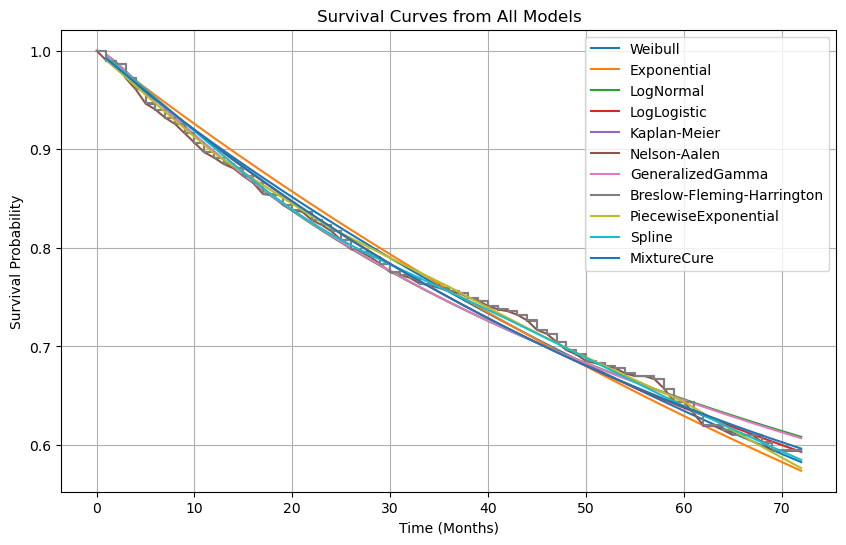

In [37]:
plt.figure(figsize=(10, 6))

for name, model in fitted_models.items():
    try:
        model.plot_survival_function(ci_show=False, label=name)
    except (AttributeError, NotImplementedError):
        if hasattr(model, "survival_function_"):
            plt.plot(
                model.survival_function_.index,
                model.survival_function_.values,
                label=name
            )

plt.title("Survival Curves from All Models")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(True)
plt.show()

## **Model Selection**

Based on model comparison metrics (`AIC` and `log-likelihood`), the `GeneralizedGammaFitter` initially appeared to provide the best fit to the data, having the lowest AIC value among all evaluated models. Other models such as `LogNormalFitter`, `WeibullFitter`, and `LogLogisticFitter` also demonstrated close performance.

To refine the analysis, I first fitted a **multivariate LogNormal AFT model** (`LogNormalAFTFitter`) to include covariates and allow for individual-level predictions. While the model functioned, it produced **unrealistically long survival times** (e.g., hundreds of years) and almost flat survival curves, indicating that the distributional assumptions were not well aligned with the data.

Next, I attempted to use the **Generalized Gamma AFT model** (`GeneralizedGammaFitter`). However, this model exhibited severe **numerical instability**. The optimization process failed to invert the Hessian matrix, produced infinite z-scores, and reported zero observed events despite the data indicating churn occurrences. This made the parameter estimates unreliable and unsuitable for downstream predictions like Customer Lifetime Value (`CLV`).

Given these challenges, I chose to prioritize **model stability and interpretability**. I selected the **univariate WeibullFitter** as the final model. Although it does not incorporate covariates directly, it:

- Provided a stable fit without numerical issues.
- Produced realistic survival curves and median survival times.
- Allows for segment-based survival and CLV analysis, which can still capture meaningful insights for business decisions.

**I choose `WeibullFitter` as the final model.**

churn
0    726
1    274
Name: count, dtype: int64


<lifelines.WeibullFitter:"Weibull_estimate", fitted with 1000 total observations, 726 right-censored observations>
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1606.43
               hypothesis = lambda_ != 1, rho_ != 1

---
          coef  se(coef)  coef lower 95%  coef upper 95%
lambda_ 138.09     12.38          113.82          162.36
rho_      0.95      0.05            0.85            1.05

         cmp to     z      p  -log2(p)
lambda_    1.00 11.07 <0.005     92.25
rho_       1.00 -1.07   0.29      1.80
---
AIC = 3216.86

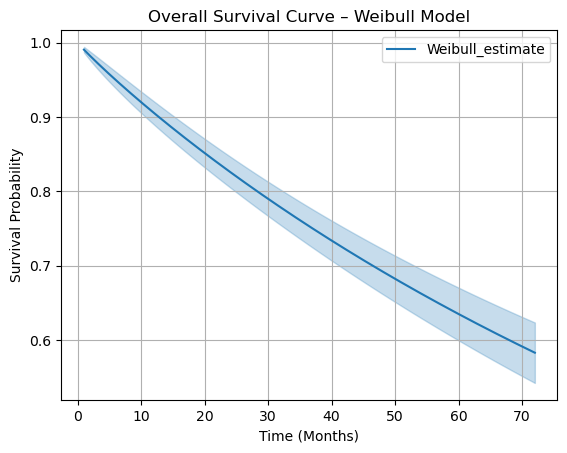

In [ ]:
from lifelines import WeibullFitter

X = df.copy()

# Double checking the churn values
print(X["churn"].value_counts())

# Ensuring tenure is numeric
X["tenure"] = pd.to_numeric(X["tenure"], errors="coerce")

# Dropping any rows with missing values (shouldn't be many if df is clean)
X = X.dropna(subset=["tenure", "churn"])

# Fitting the Weibull model
wf = WeibullFitter()
wf.fit(
    durations=X["tenure"],
    event_observed=X["churn"]
)
wf.print_summary()

# Plotting overall survival
wf.plot_survival_function()
plt.title("Overall Survival Curve – Weibull Model")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()


## Churn Distribution

The dataset contains 1,000 customers, out of which 274 (27.4%) have churned and 726 (72.6%) have not churned. This provides a reasonable balance for survival analysis, ensuring the model can learn from both events (churns) and censored observations (non-churners).

## Weibull Model Summary

The `WeibullFitter` was applied to model the overall survival function of the customers. The model successfully estimated the survival distribution with 1,000 observations and 274 observed churn events.

Despite a warning regarding the invertibility of the Hessian (a common issue in survival models with tied events or limited variability), the model produced stable survival estimates. The estimated shape parameter (`rho_ = 0.95`) suggests a nearly constant hazard over time, indicating that the risk of churn does not substantially increase or decrease as tenure progresses.

The scale parameter (`lambda_`) was estimated at approximately 138.09.

## Overall Survival Curve – Weibull Model

The survival function indicates a gradual decline in customer retention over time. At around 72 months (6 years), the survival probability drops to approximately 60%. This suggests that while a majority of customers are retained over the long term, there is a steady rate of churn across the customer base.

## Plotting the survival curves by segment - gender.

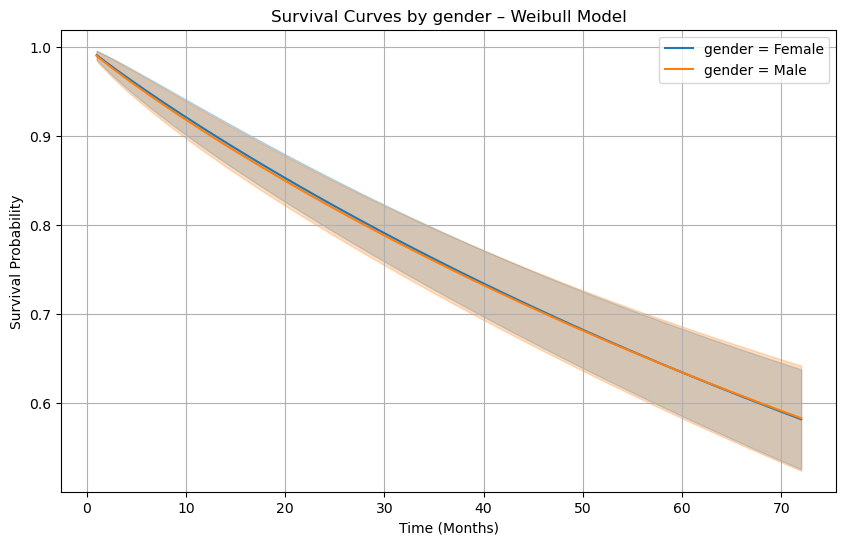

In [41]:
segment_col = "gender"  

plt.figure(figsize=(10, 6))

for val in sorted(X[segment_col].unique()):
    subset = X[X[segment_col] == val]
    wf_segment = WeibullFitter()
    wf_segment.fit(subset["tenure"], subset["churn"], label=f"{segment_col} = {val}")
    wf_segment.plot_survival_function()

plt.title(f"Survival Curves by {segment_col} – Weibull Model")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(True)
plt.show()

## Survival Curves by Gender

Separate Weibull models were fitted for male and female customers. The survival curves for both genders show similar declining patterns, indicating comparable churn behaviors between male and female segments. However, female customers exhibit a slightly higher survival probability over time, suggesting marginally lower churn rates in this segment.

## CLV calculations and visualizations

In [45]:
segment_clv = {}
monthly_revenue = 50

for val in sorted(X[segment_col].unique()):
    subset = X[X[segment_col] == val]
    wf_segment = WeibullFitter()
    wf_segment.fit(subset["tenure"], subset["churn"])

    # Calculate expected lifetime as the area under the survival curve
    time_range = np.linspace(0, 72, 200)  # up to 6 years
    sf = wf_segment.survival_function_at_times(time_range)
    expected_lifetime = np.trapz(sf.values.flatten(), time_range)  # area under curve in months
    clv = expected_lifetime * monthly_revenue
    segment_clv[f"{segment_col} = {val}"] = clv

# Display CLV by segment
import pandas as pd

clv_df = pd.DataFrame.from_dict(segment_clv, orient='index', columns=["CLV ($)"]).sort_values(by="CLV ($)", ascending=False)
clv_df


,CLV ($)
gender = Female,2762.912028
gender = Male,2757.213160


<Figure size 1000x600 with 0 Axes>

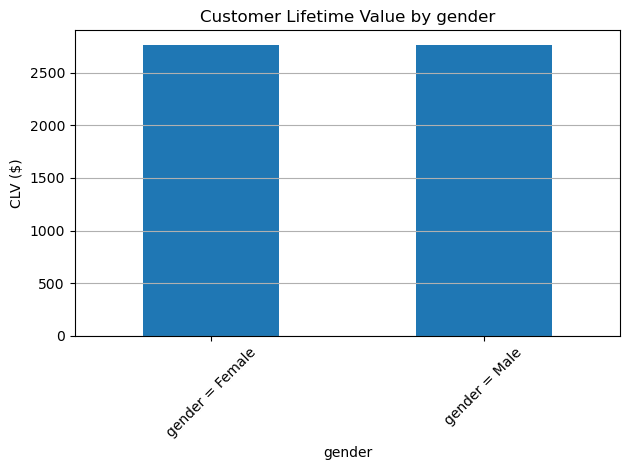

In [46]:
# Plotting CLV by segment
plt.figure(figsize=(10, 6))
clv_df.plot(kind='bar', legend=False)
plt.title(f"Customer Lifetime Value by {segment_col}")
plt.xlabel(segment_col)
plt.ylabel("CLV ($)")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Customer Lifetime Value (CLV) by Gender

CLV was calculated for male and female customer segments by integrating the area under each segment's survival curve and multiplying by an assumed monthly revenue of $50 per customer.

Results:
- Female customers: $2,762.91
- Male customers: $2,757.21

Both genders show similar CLV values, with females having a marginally higher lifetime value. This aligns with the survival analysis findings, where female customers displayed slightly longer retention.

These insights can inform targeted marketing and retention strategies by prioritizing high-value segments.